In [1]:
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path("../")

DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "cifar10"

TRAIN_DIR = DATASET_DIR / "cifar10/train"

TEST_DIR = DATASET_DIR / "cifar10/test"

In [3]:
classes = sorted(
    [
        folder.name
        for folder in TRAIN_DIR.iterdir()
        if folder.is_dir()
    ]
)

print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


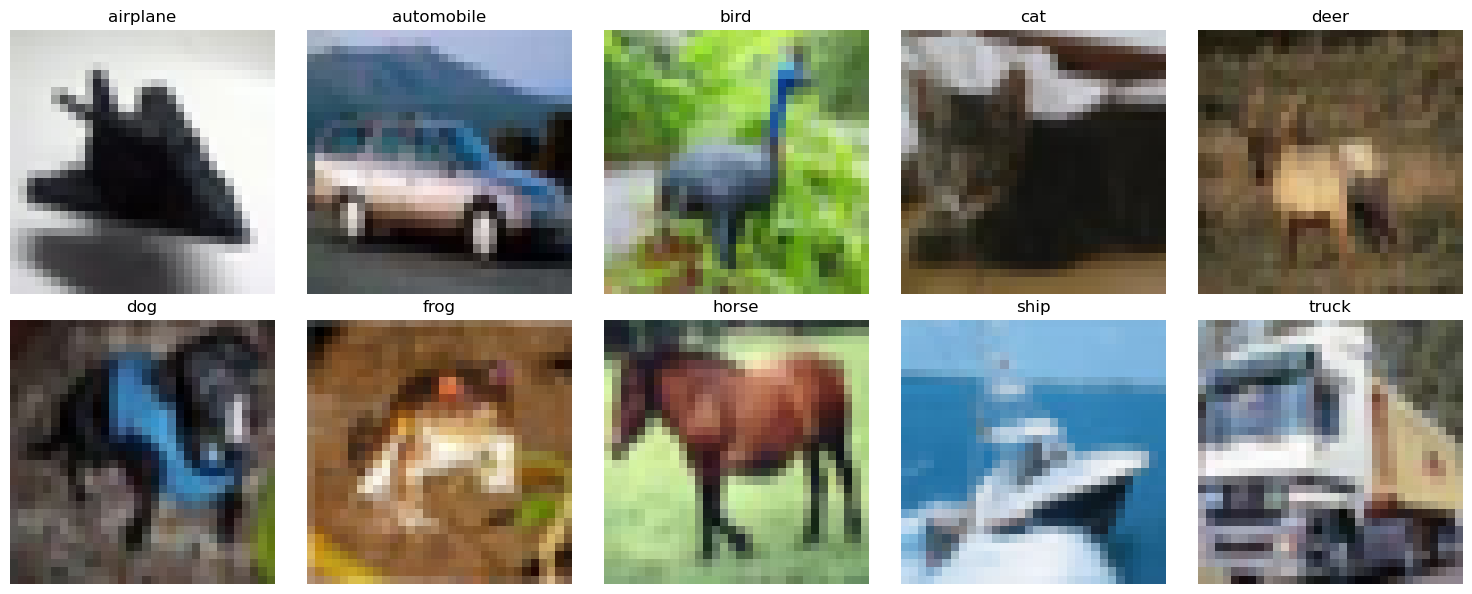

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

axes = axes.flatten()

for ax, class_name in zip(axes, classes):

    image_path = next((TRAIN_DIR / class_name).glob("*"))

    image = cv2.imread(str(image_path))

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ax.imshow(image)

    ax.set_title(class_name)

    ax.axis("off")

plt.tight_layout()

plt.show()

In [5]:
sample_path = next((TRAIN_DIR / classes[0]).glob("*"))

image = cv2.imread(str(sample_path))

print("Shape :", image.shape)

print("Data Type :", image.dtype)

print("Minimum Pixel :", image.min())

print("Maximum Pixel :", image.max())

Shape : (32, 32, 3)
Data Type : uint8
Minimum Pixel : 2
Maximum Pixel : 254


In [6]:
image_sizes = Counter()

for class_name in classes:

    for image_path in (TRAIN_DIR / class_name).glob("*"):

        image = cv2.imread(str(image_path))

        image_sizes[image.shape] += 1

image_sizes

Counter({(32, 32, 3): 50000})

In [ ]:
extensions = Counter()

for class_name in classes:

    for image_path in (TRAIN_DIR / class_name).glob("*"):

        extensions[image_path.suffix.lower()] += 1

extensions

In [ ]:
corrupted_images = []

for class_name in classes:

    for image_path in (TRAIN_DIR / class_name).glob("*"):

        image = cv2.imread(str(image_path))

        if image is None:

            corrupted_images.append(image_path)

print(f"Corrupted Images: {len(corrupted_images)}")

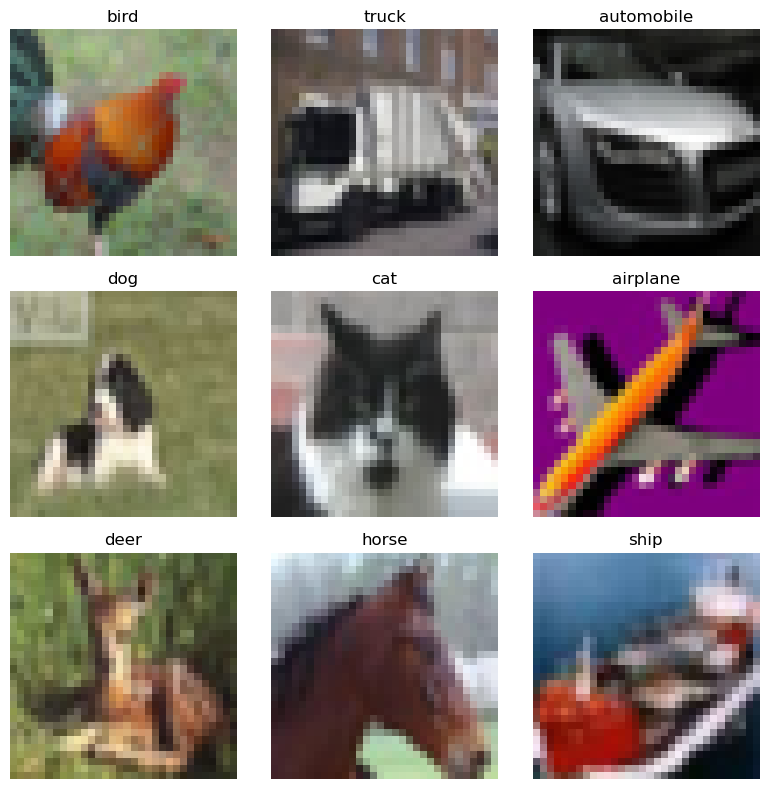

In [7]:
import random

fig, axes = plt.subplots(3, 3, figsize=(8, 8))

axes = axes.flatten()

random_images = []

for _ in range(9):

    class_name = random.choice(classes)

    image_path = random.choice(
        list((TRAIN_DIR / class_name).glob("*"))
    )

    random_images.append((class_name, image_path))

for ax, (label, path) in zip(axes, random_images):

    image = cv2.imread(str(path))

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ax.imshow(image)

    ax.set_title(label)

    ax.axis("off")

plt.tight_layout()

plt.show()